# Exploratory Data Analysis and Feature Engineering
## Heart Disease Dataset

This project performs:

- Dataset understanding
- Data quality checking
- Missing-value analysis
- Duplicate detection
- Validity and range checking
- Univariate analysis
- Bivariate analysis
- Correlation analysis
- Outlier analysis
- Data cleaning
- Feature engineering
- Final validation

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv("Heart.csv")

### Dataset Samples

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [5]:
df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
432,63,M,ASY,170,177,0,Normal,84,Y,2.5,Down,1
504,62,M,ASY,158,210,1,Normal,112,Y,3.0,Down,1
903,56,M,ATA,130,221,0,LVH,163,N,0.0,Up,0
208,28,M,ATA,130,132,0,LVH,185,N,0.0,Up,0
194,41,F,ATA,125,184,0,Normal,180,N,0.0,Up,0


## Dataset Information

In [6]:
print(df.shape)
print("Rows: ",df.shape[0])
print("Columns: ",df.shape[1])

(918, 12)
Rows:  918
Columns:  12


### The dataset contains 918 patient records and 12 variables.

In [7]:
df.size

11016

In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


#### This identifies: * data types   * number of non-null values  * numerical columns  * categorical columns

In [10]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


#### This gives: * mean * standard deviation * minimum * quartiles * maximum

In [11]:
df.describe(include="object")

/var/folders/44/fywnm5sj335fdzvrq6s4_m3c0000gn/T/ipykernel_6779/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


#### This shows the number of unique categories and the most frequent category for each categorical feature.

## Missing Values

In [12]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

#### There is no null value in the dataset in any column

## Duplicate rows

In [13]:
df.duplicated().sum()

np.int64(0)

#### There is no dupliacte value

## Unique Values

In [14]:
df.nunique().sum()

np.int64(529)

In [15]:
for column in df.columns:
    print(column, ":", df[column].unique(),"\n")

Age : [40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71] 

Sex : <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str 

ChestPainType : <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str 

RestingBP : [140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164] 

Cholesterol : [289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161 228 

### Numerical Columns

In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns
print("Numerical Columns:",numerical_columns)

Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='str')


### Categorical Columns

In [17]:
categorical_columns = df.select_dtypes(include=["object","str"]).columns
print("\nCategorical Columns:",categorical_columns)


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


In [18]:
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [19]:
expected_categories = {
    "Sex": {"M", "F"},
    "ChestPainType": {"ATA", "NAP", "ASY", "TA"},
    "RestingECG": {"Normal", "ST", "LVH"},
    "ExerciseAngina": {"Y", "N"},
    "ST_Slope": {"Up", "Flat", "Down"}
}
for column, expected in expected_categories.items():
    actual = set(df[column].dropna().unique())
    invalid = actual - expected
    print(column)
    print("Invalid values:", invalid)
    print()

Sex
Invalid values: set()

ChestPainType
Invalid values: set()

RestingECG
Invalid values: set()

ExerciseAngina
Invalid values: set()

ST_Slope
Invalid values: set()



In [20]:
print("FastingBS values:", sorted(df["FastingBS"].unique()))
print("HeartDisease values:", sorted(df["HeartDisease"].unique()))

FastingBS values: [np.int64(0), np.int64(1)]
HeartDisease values: [np.int64(0), np.int64(1)]


In [21]:
range_check = pd.DataFrame({
    "Minimum": df[[
        "Age",
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "MaxHR",
        "Oldpeak"
    ]].min(),
    "Maximum": df[[
        "Age",
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "MaxHR",
        "Oldpeak"
    ]].max()
})
range_check

,Minimum,Maximum
Age,28.0,77.0
RestingBP,0.0,200.0
Cholesterol,0.0,603.0
FastingBS,0.0,1.0
MaxHR,60.0,202.0
Oldpeak,-2.6,6.2


In [22]:
checks = {
    "Age below 18": (df["Age"] < 18).sum(),
    "RestingBP equal to 0": (df["RestingBP"] == 0).sum(),
    "Cholesterol equal to 0": (df["Cholesterol"] == 0).sum(),
    "FastingBS outside 0/1": (~df["FastingBS"].isin([0, 1])).sum(),
    "MaxHR <= 0": (df["MaxHR"] <= 0).sum(),
    "HeartDisease outside 0/1": (~df["HeartDisease"].isin([0, 1])).sum()
}
pd.Series(checks)

Age below 18                  0
RestingBP equal to 0          1
Cholesterol equal to 0      172
FastingBS outside 0/1         0
MaxHR <= 0                    0
HeartDisease outside 0/1      0
dtype: int64

#### The zero values in RestingBP and Cholesterol are therefore important data-quality issues.

In [23]:
print("RestingBP = 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())
print("FastingBS = 0:", (df["FastingBS"] == 0).sum())

RestingBP = 0: 1
Cholesterol = 0: 172
FastingBS = 0: 704


#### Zero is not a meaningful measurement for RestingBP or Cholesterol , FastingBS zeros are valid because this is a binary feature

In [24]:
print("Negative Oldpeak values:", (df["Oldpeak"] < 0).sum())
print(df.loc[df["Oldpeak"] < 0, "Oldpeak"].value_counts())

Negative Oldpeak values: 13
Oldpeak
-0.1    2
-1.0    2
-0.5    2
-0.9    1
-2.6    1
-1.5    1
-1.1    1
-0.7    1
-0.8    1
-2.0    1
Name: count, dtype: int64


### Heart Disease Distribution

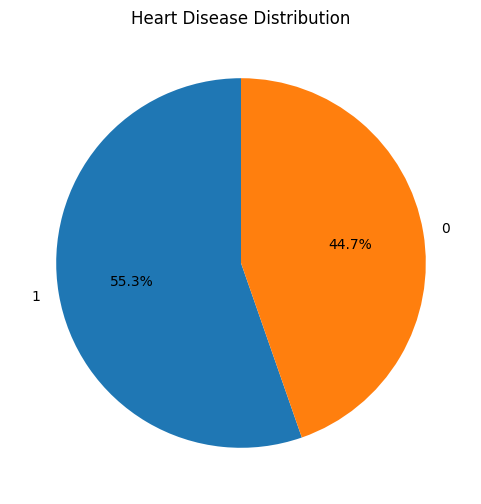

In [25]:
plt.figure(figsize=(6, 6))
df["HeartDisease"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Heart Disease Distribution")
plt.ylabel("")
plt.show()

#### This shows the proportion of patients with and without heart disease, both have almost equal ratio. Peron with heart disease are 55.3% and without disease are 44.7%

In [26]:
target_counts = df["HeartDisease"].value_counts()
print(target_counts)
print()
print((target_counts / len(df) * 100).round(2))

HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease
1    55.34
0    44.66
Name: count, dtype: float64


### Gender Distribution

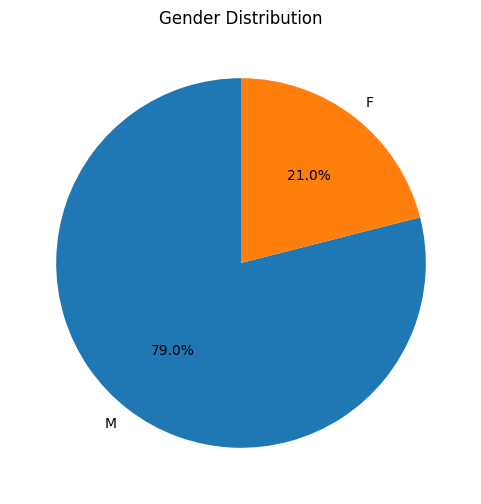

In [27]:
plt.figure(figsize=(6, 6))
df["Sex"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

#### The dataset is strongly dominated by male patients.

### Gender vs heart disease

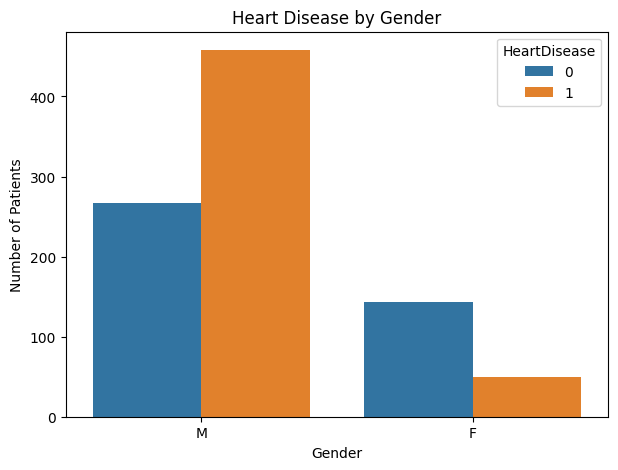

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex",  hue="HeartDisease")
plt.title("Heart Disease by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

#### This compares heart-disease outcomes between males and females.

### Gender-wise heart disease percentage

In [29]:
gender_target = pd.crosstab(df["Sex"], df["HeartDisease"], normalize="index") * 100
print(gender_target)

HeartDisease          0          1
Sex                               
F             74.093264  25.906736
M             36.827586  63.172414


### Chest pain distribution

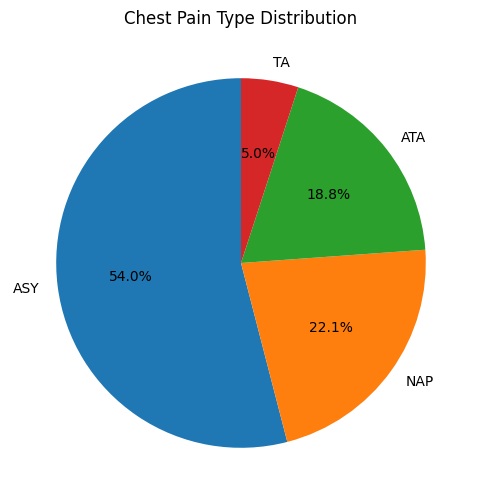

In [30]:
plt.figure(figsize=(6, 6))
df["ChestPainType"].value_counts().plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Chest Pain Type Distribution")
plt.ylabel("")
plt.show()

#### ASY is the most common chest-pain category.

### Chest pain vs heart disease

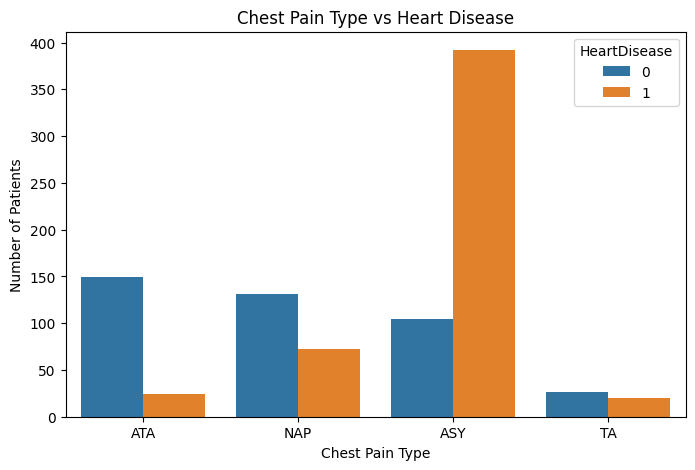

In [31]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ChestPainType", hue="HeartDisease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.show()

In [32]:
chest_target = pd.crosstab(df["ChestPainType"], df["HeartDisease"], normalize="index") * 100
print(chest_target)

HeartDisease           0          1
ChestPainType                      
ASY            20.967742  79.032258
ATA            86.127168  13.872832
NAP            64.532020  35.467980
TA             56.521739  43.478261


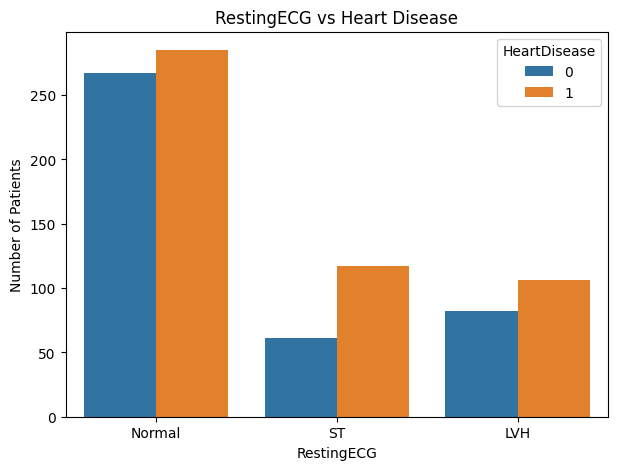

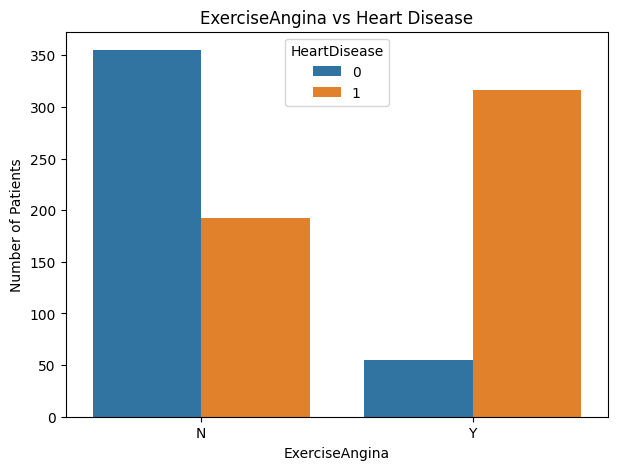

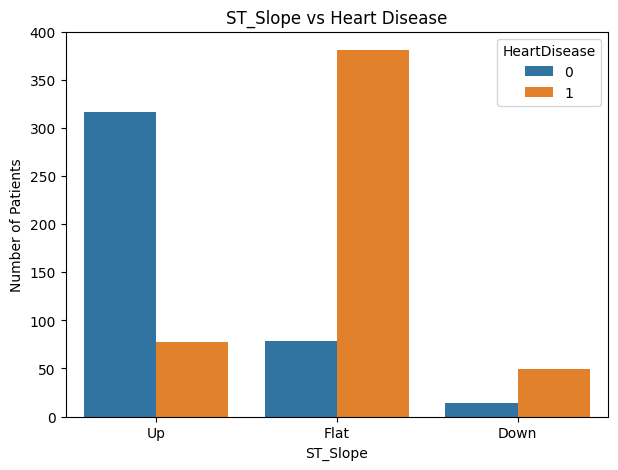

In [33]:
for column in ["RestingECG", "ExerciseAngina", "ST_Slope"]:
    plt.figure(figsize=(7, 5))    
    sns.countplot(data=df, x=column, hue="HeartDisease")
    plt.title(f"{column} vs Heart Disease")
    plt.xlabel(column)
    plt.ylabel("Number of Patients")
    plt.show()

## Numerical Data

In [34]:
continuous_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "MaxHR",
    "Oldpeak"
]
print(continuous_columns)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


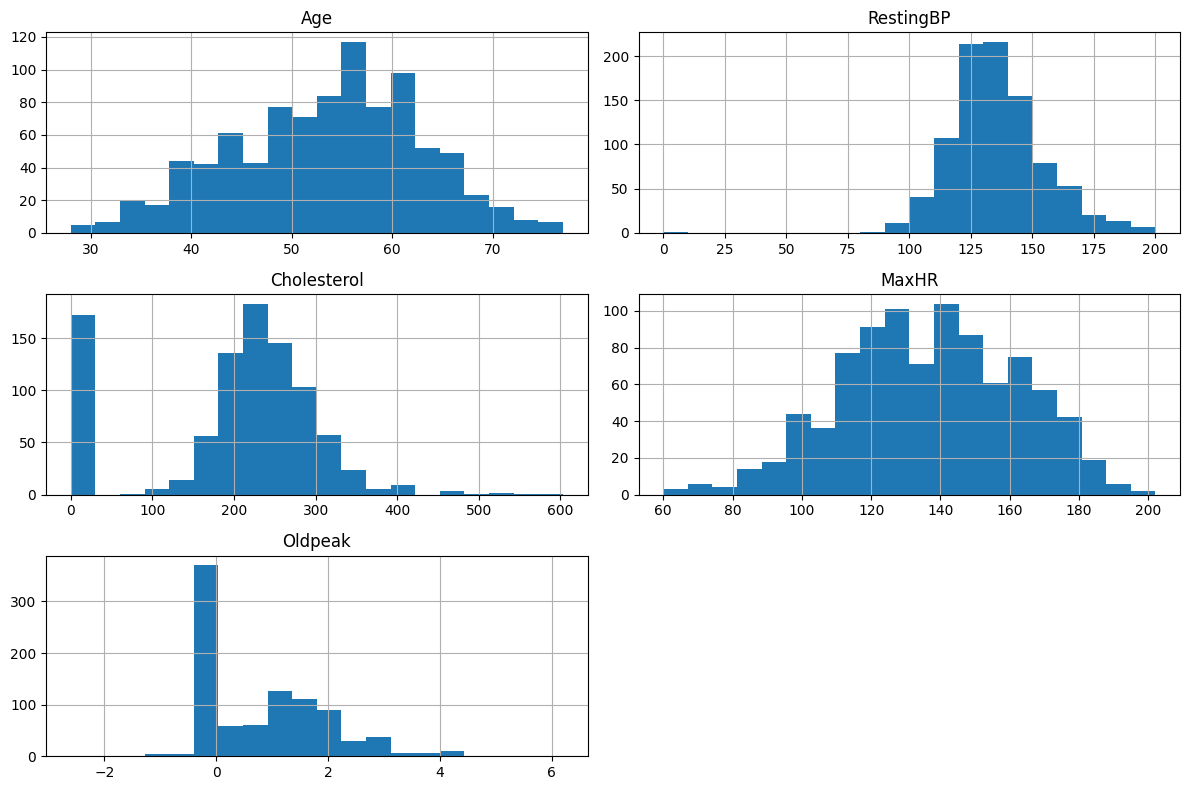

In [35]:
df[continuous_columns].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

#### Histograms show the shape and spread of continuous numerical variables
#### They help identify: * skewness * concentration * unusual values * possible outliers




### Boxplot

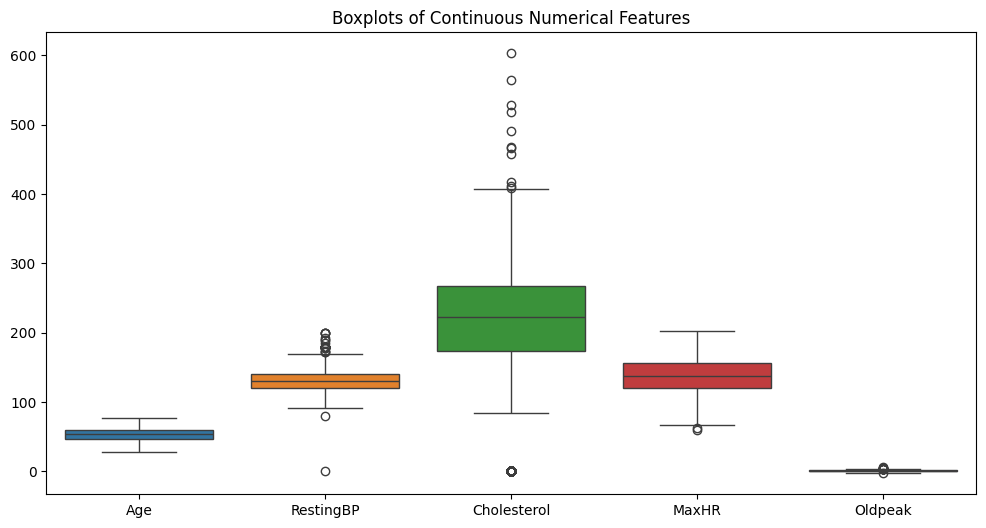

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_columns])
plt.title("Boxplots of Continuous Numerical Features")
plt.show()

#### Cholesterol has particularly noticeable extreme values.

### Cholesterol categories

In [37]:
print("Cholesterol = 0:", (df["Cholesterol"] == 0).sum())
print("\nCholesterol > 240:")
print((df["Cholesterol"] > 240).sum())
print("\nMaximum cholesterol:", df["Cholesterol"].max())

Cholesterol = 0: 172

Cholesterol > 240:
355

Maximum cholesterol: 603


In [38]:
cholesterol_valid = df.loc[df["Cholesterol"] > 0, "Cholesterol"]
cholesterol_category = pd.cut( cholesterol_valid, bins=[0, 199, 239, np.inf],
    labels=[
        "Desirable",
        "Borderline High",
        "High"
    ]
)
cholesterol_category.value_counts()

Cholesterol
High               363
Borderline High    237
Desirable          146
Name: count, dtype: int64

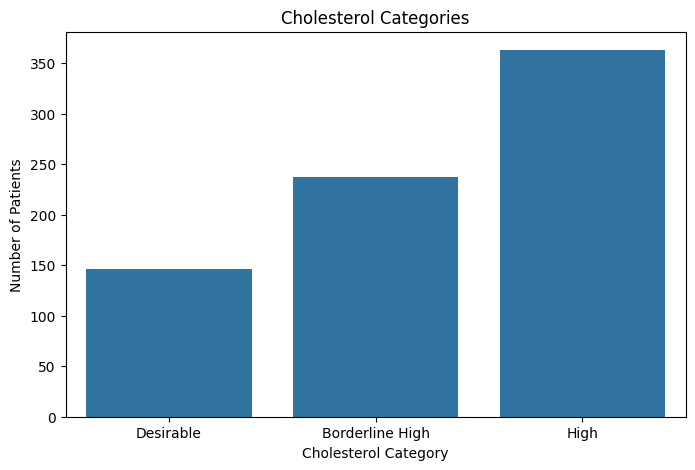

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x=cholesterol_category)
plt.title("Cholesterol Categories")
plt.xlabel("Cholesterol Category")
plt.ylabel("Number of Patients")
plt.show()

#### This shows how the observed cholesterol measurements are distributed across desirable, borderline-high and high ranges.

### Blood pressure categories

In [40]:
def bp_category(bp):
    if bp < 120:
        return "Normal"
    elif bp < 130:
        return "Elevated"
    elif bp < 140:
        return "Stage 1"
    else:
        return "Stage 2 or Higher"
bp_categories = df["RestingBP"].apply(bp_category)
print(bp_categories.value_counts())

RestingBP
Stage 2 or Higher    327
Stage 1              216
Elevated             214
Normal               161
Name: count, dtype: int64


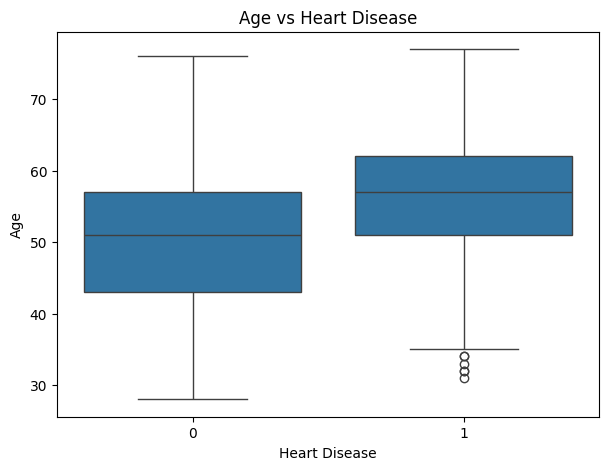

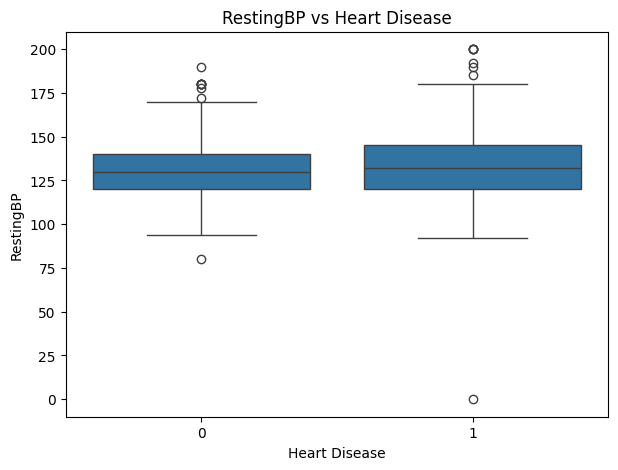

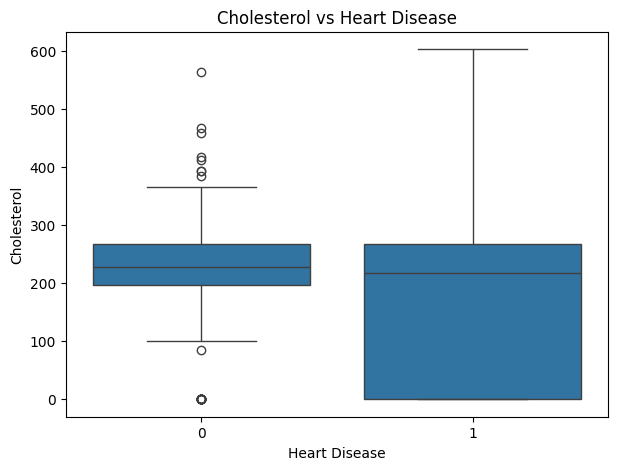

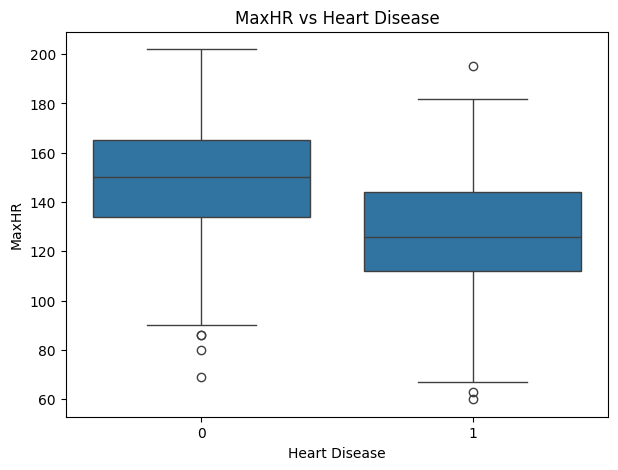

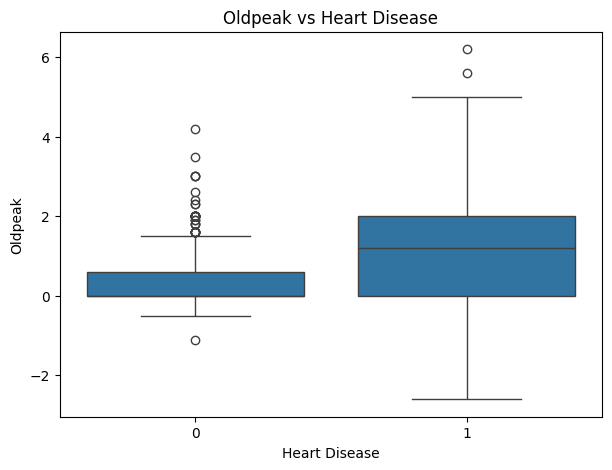

In [41]:
for column in continuous_columns:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="HeartDisease", y=column)
    plt.title(f"{column} vs Heart Disease")
    plt.xlabel("Heart Disease")
    plt.ylabel(column)
    plt.show()

### Correlation

In [42]:
correlation = df[continuous_columns + ["HeartDisease"]].corr()
correlation.round(2)

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
Age,1.00,0.25,-0.10,-0.38,0.26,0.28
RestingBP,0.25,1.00,0.10,-0.11,0.16,0.11
Cholesterol,-0.10,0.10,1.00,0.24,0.05,-0.23
MaxHR,-0.38,-0.11,0.24,1.00,-0.16,-0.40
Oldpeak,0.26,0.16,0.05,-0.16,1.00,0.40
HeartDisease,0.28,0.11,-0.23,-0.40,0.40,1.00


### Heatmap

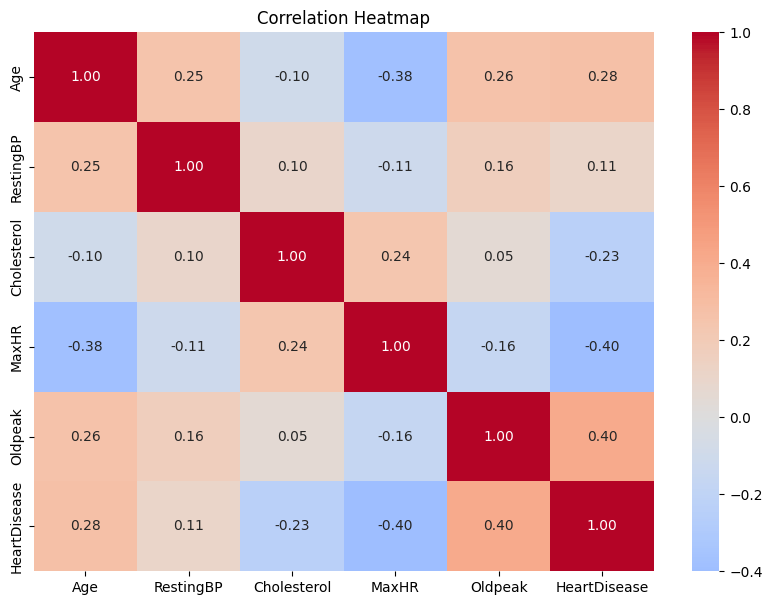

In [43]:
plt.figure(figsize=(10, 7))
sns.heatmap(correlation,annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

### Scatter plot

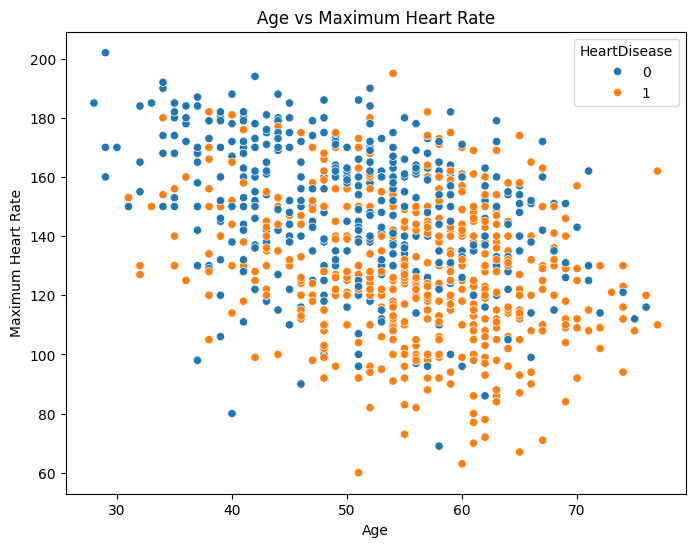

In [44]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age",y="MaxHR", hue="HeartDisease")
plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.show()

#### This helps examine how maximum heart rate changes with age and whether the two heart-disease groups show different patterns.

### Outliers

In [45]:
outlier_summary = []
for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_summary.append([column, Q1,Q3, lower, upper,count])
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
        ])
outlier_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,Age,47.00,60.0,27.500,79.500,0
1,RestingBP,120.00,140.0,90.000,170.000,28
2,Cholesterol,173.25,267.0,32.625,407.625,183
3,MaxHR,120.00,156.0,66.000,210.000,2
4,Oldpeak,0.00,1.5,-2.250,3.750,16


In [46]:
for column in continuous_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)][column]
    print("\n", column)
    print(outliers.sort_values().tolist())


 Age
[]

 RestingBP
[0, 80, 172, 172, 174, 178, 178, 178, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 185, 190, 190, 192, 200, 200, 200, 200]

 Cholesterol
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 409, 412, 417, 458, 466, 468, 491, 518, 529, 564, 603]

 MaxHR
[60, 63]

 Oldpeak
[-2.6, 3.8, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.2, 4.2, 4.4, 5.0, 5.6, 6.2]


## Feature Engineering

In [47]:
df_clean = df.copy()

In [48]:
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

In [49]:
df_clean.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [50]:
df_clean["RestingBP"] = df_clean["RestingBP"].fillna(df_clean["RestingBP"].median())
df_clean["Cholesterol"] = df_clean["Cholesterol"].fillna(df_clean["Cholesterol"].median())

In [51]:
print("Missing values:")
print(df_clean.isnull().sum())
print("\nZero RestingBP:", (df_clean["RestingBP"] == 0).sum())
print("Zero Cholesterol:", (df_clean["Cholesterol"] == 0).sum())

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero RestingBP: 0
Zero Cholesterol: 0


In [52]:
df_clean["AgeGroup"] = pd.cut(df_clean["Age"],  bins=[0, 39, 49, 59, 69, 100],
    labels=[
        "Below 40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ])

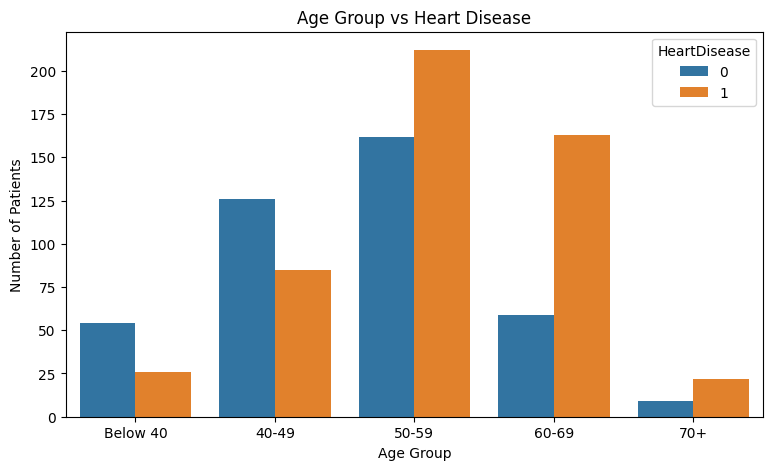

In [53]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x="AgeGroup", hue="HeartDisease")
plt.title("Age Group vs Heart Disease")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.show()

#### This allows us to compare heart-disease outcomes across different age groups.

In [54]:
df_clean["MaxHR_Percent"] = (df_clean["MaxHR"] / (220 - df_clean["Age"])) * 100

#### This creates a relative heart-rate feature instead of depending only on raw MaxHR.

In [55]:
def bp_category(bp):
    if bp < 120:
        return "Normal"
    elif bp < 130:
        return "Elevated"
    elif bp < 140:
        return "Stage 1"
    else:
        return "Stage 2 or Higher"
df_clean["BPCategory"] = df_clean["RestingBP"].apply(bp_category)

#### This creates a categorical version of resting systolic blood pressure.

In [56]:
def cholesterol_category(value):
    if value < 200:
        return "Desirable"
    elif value < 240:
        return "Borderline High"
    else:
        return "High"
df_clean["CholesterolCategory"] = (df_clean["Cholesterol"].apply(cholesterol_category))

#### This creates an analytical cholesterol category.

In [57]:
print(df_clean[[
            "Age",
            "AgeGroup",
            "RestingBP",
            "BPCategory",
            "Cholesterol",
            "CholesterolCategory",
            "MaxHR",
            "MaxHR_Percent"
        ]].head())

   Age  AgeGroup  RestingBP         BPCategory  Cholesterol  \
0   40     40-49      140.0  Stage 2 or Higher        289.0   
1   49     40-49      160.0  Stage 2 or Higher        180.0   
2   37  Below 40      130.0            Stage 1        283.0   
3   48     40-49      138.0            Stage 1        214.0   
4   54     50-59      150.0  Stage 2 or Higher        195.0   

  CholesterolCategory  MaxHR  MaxHR_Percent  
0                High    172      95.555556  
1           Desirable    156      91.228070  
2                High     98      53.551913  
3     Borderline High    108      62.790698  
4           Desirable    122      73.493976  


#### This verifies that the newly engineered features have been created correctly.

In [58]:
categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope",
    "AgeGroup",
    "BPCategory",
    "CholesterolCategory"
]
df_model = pd.get_dummies( df_clean,columns=categorical_features, drop_first=True, dtype=int)

In [59]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Model-ready shape:", df_model.shape)

Original shape: (918, 12)
Cleaned shape: (918, 16)
Model-ready shape: (918, 26)


In [64]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [63]:
df_clean.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease', 'AgeGroup', 'MaxHR_Percent', 'BPCategory',
       'CholesterolCategory'],
      dtype='str')

In [60]:
print("Total missing values:", df_model.isnull().sum().sum())

Total missing values: 0


In [61]:
print("Duplicate rows:", df_model.duplicated().sum())

Duplicate rows: 0


In [62]:
print(df_model["HeartDisease"].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64
